# Classification Part A

This notebook compares five classification models on the airline passenger satisfaction dataset. The task is binary classification: predict whether a passenger is satisfied or not.

The data was already cleaned and preprocessed in the EDA notebook. Here we load the raw splits and let the pipeline handle encoding and scaling inside each cross-validation fold.

In [2]:
# imports for classification pipeline and evaluation
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from threadpoolctl import threadpool_limits

sns.set_theme(style="whitegrid", palette="colorblind")
limits = threadpool_limits(limits=4)
pd.set_option("display.max_colwidth", 120)

## Data

In [3]:
# load raw splits so the pipeline can fit preprocessing inside CV folds
train = pd.read_csv("../processed_datasets/airline_train_raw.csv")
test = pd.read_csv("../processed_datasets/airline_test_raw.csv")
x_train = train.drop(columns="satisfaction")
y_train = train["satisfaction"]
x_test = test.drop(columns="satisfaction")
y_test = test["satisfaction"]
print("Training:", x_train.shape, "Test:", x_test.shape)

Training: (83123, 23) Test: (20781, 23)


In [4]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

num = x_train.select_dtypes(include="number").columns.tolist()
cat = x_train.select_dtypes(include=["str", "object", "category"]).columns.tolist()
num_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])
prep = ColumnTransformer([("num", num_pipe, num), ("cat", cat_pipe, cat)], verbose_feature_names_out=False)

In [5]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
x_tune, _, y_tune, _ = train_test_split(
    x_train, y_train, train_size=6000, stratify=y_train, random_state=42
)
scoring = "f1_weighted"

We use 6,000 stratified rows for the grid search to keep things fast. Stratified means both classes stay in roughly the same proportion as the full dataset. The final model always trains on all ~83k training rows.

The search uses 6,000 training rows and three folds to keep runtime reasonable. Each final model uses the full training set. Preprocessing is fitted inside each fold, and the test set is kept out of tuning.

In [6]:
# verify that our pipeline matches the pre-saved processed features
saved = pd.read_csv("../processed_datasets/airline_train.csv").drop(columns="satisfaction")
check = clone(prep).fit_transform(x_train)
assert np.allclose(check, saved.to_numpy(), rtol=1e-7, atol=1e-7)
rows = []
tune_rows = []
fitted = {}
predictions = {}
scores_test = {}

## Common evaluation functions

In [7]:
# tune() does grid search on the 6k subset, returns best pipeline config
def tune(name, pipe, grid):
    base = cross_val_score(pipe, x_tune, y_tune, cv=cv, scoring=scoring).mean()
    search = GridSearchCV(pipe, grid, cv=cv, scoring=scoring, n_jobs=1)
    search.fit(x_tune, y_tune)
    row = {"Model": name, "Baseline CV": base, "Tuned CV": search.best_score_,
           "Change": search.best_score_ - base, "Best parameters": search.best_params_}
    tune_rows.append(row)
    display(pd.DataFrame([row]))
    return clone(search.best_estimator_)

In [8]:
# evaluate() trains on full training data and computes test metrics
def evaluate(name, pipe):
    start = time.perf_counter()
    pipe.fit(x_train, y_train)
    seconds = time.perf_counter() - start
    pred = pipe.predict(x_test)
    if hasattr(pipe, "predict_proba"):
        score = pipe.predict_proba(x_test)[:, 1]
    else:
        score = pipe.decision_function(x_test)
    fitted[name] = pipe
    predictions[name] = pred
    scores_test[name] = score
    row = get_metrics(name, pred, score, seconds)
    rows.append(row)
    display(pd.DataFrame([row]).round(4))

In [9]:
# get_metrics() computes accuracy, precision, recall, F1, ROC-AUC
def get_metrics(name, pred, score, seconds):
    return {"Model": name, "Accuracy": accuracy_score(y_test, pred),
            "Precision weighted": precision_score(y_test, pred, average="weighted", zero_division=0),
            "Recall weighted": recall_score(y_test, pred, average="weighted", zero_division=0),
            "F1 weighted": f1_score(y_test, pred, average="weighted"),
            "ROC-AUC": roc_auc_score(y_test, score), "Fit seconds": seconds}

def show_cm(name):
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions[name], display_labels=["Not satisfied", "Satisfied"], cmap="Blues", colorbar=False
    )
    plt.title(name)
    plt.tight_layout()
    plt.show()

Precision, recall, and F1 use class weights. Satisfied is the positive class for ROC-AUC. In each confusion matrix, rows are actual labels and columns are predictions. 'Not satisfied' includes neutral passengers.

We're using weighted metrics because the classes are slightly imbalanced (57/43 split). Weighted F1 accounts for this by giving each class a weight proportional to its size. ROC-AUC is threshold-independent, so it tells us how well the model separates the two classes overall.

## 1. Logistic Regression

Logistic regression provides a simple baseline for the two satisfaction classes.

,Model,Accuracy,Precision weighted,Recall weighted,F1 weighted,ROC-AUC,Fit seconds
0,Logistic Regression,0.8766,0.8764,0.8766,0.8763,0.9294,0.4731


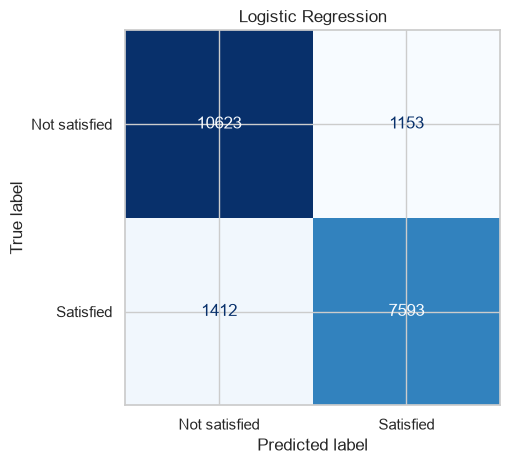

In [10]:
from sklearn.linear_model import LogisticRegression

lr = Pipeline([("prep", clone(prep)), ("model", LogisticRegression(max_iter=3000, random_state=42))])
evaluate("Logistic Regression", lr)
show_cm("Logistic Regression")

Logistic Regression correctly classifies 87.66% of test passengers, with weighted F1 0.8763.

87.66% accuracy is a solid baseline for a linear model. But remember that just predicting "not satisfied" for everyone would give ~57% accuracy, so the model is clearly learning real patterns. The odds ratios tell us which features push the prediction toward satisfaction.

In [11]:
names = lr.named_steps["prep"].get_feature_names_out()
coef = lr.named_steps["model"].coef_[0]
odds = pd.DataFrame({"Feature": names, "Coefficient": coef, "Odds ratio": np.exp(coef)})
order = odds["Coefficient"].abs().sort_values(ascending=False).index
display(odds.loc[order].head(8).round(4))
encoder = lr.named_steps["prep"].named_transformers_["cat"].named_steps["encode"]
display(pd.DataFrame({"Category": cat, "Reference": [values[0] for values in encoder.categories_]}))

,Feature,Coefficient,Odds ratio
21,Type of Travel_Personal Travel,-2.7408,0.0645
20,Customer Type_disloyal Customer,-2.0938,0.1232
23,Class_Eco Plus,-0.8903,0.4105
22,Class_Eco,-0.7706,0.4627
7,Online boarding,0.7625,2.1437
2,Inflight wifi service,0.4688,1.5981
17,Arrival Delay in Minutes,-0.3713,0.6898
18,service_mean,0.3596,1.4327


,Category,Reference
0,Gender,Female
1,Customer Type,Loyal Customer
2,Type of Travel,Business travel
3,Class,Business


An odds ratio above 1 increases the odds of satisfaction. For numeric inputs it refers to a one-standard-deviation increase. For encoded categories it compares with the reference category shown above.

Looking at the top coefficients, online boarding and inflight wifi seem to matter a lot. This lines up with what we saw in the EDA correlation heatmap. The model is picking up the same signals we noticed during exploration.

## 2. KNN

The search compares k values and two distances. p=1 uses Manhattan distance and p=2 uses Euclidean distance. Numeric features are scaled before calculating distances.

,Model,Baseline CV,Tuned CV,Change,Best parameters
0,KNN,0.890553,0.907538,0.016986,"{'model__n_neighbors': 5, 'model__p': 1}"


,Model,Accuracy,Precision weighted,Recall weighted,F1 weighted,ROC-AUC,Fit seconds
0,KNN,0.9334,0.9334,0.9334,0.9332,0.9745,0.2959


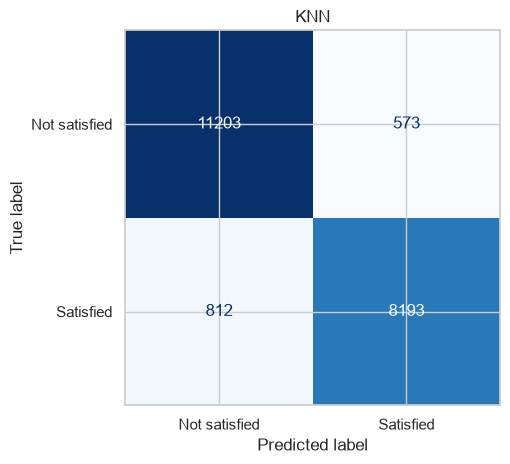

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline([("prep", clone(prep)), ("model", KNeighborsClassifier(n_neighbors=5, n_jobs=2))])
grid = {"model__n_neighbors": [5, 15, 25], "model__p": [1, 2]}
knn = tune("KNN", knn, grid)
evaluate("KNN", knn)
show_cm("KNN")

KNN correctly classifies 93.34% of test passengers, with weighted F1 0.9332. Tuning changed the mean CV score by +0.01699.

KNN jumped to 93.3% accuracy, which is a big improvement over logistic regression. This suggests the decision boundary between satisfied and not-satisfied passengers isn't a simple straight line. KNN can capture more complex, local patterns in the data.

## 3. Gaussian Naive Bayes

Gaussian Naive Bayes assumes predictors are conditionally independent within each class. The correlated service ratings and binary features do not fully match its assumptions.

,Model,Accuracy,Precision weighted,Recall weighted,F1 weighted,ROC-AUC,Fit seconds
0,Gaussian Naive Bayes,0.8619,0.8617,0.8619,0.8615,0.9216,0.3215


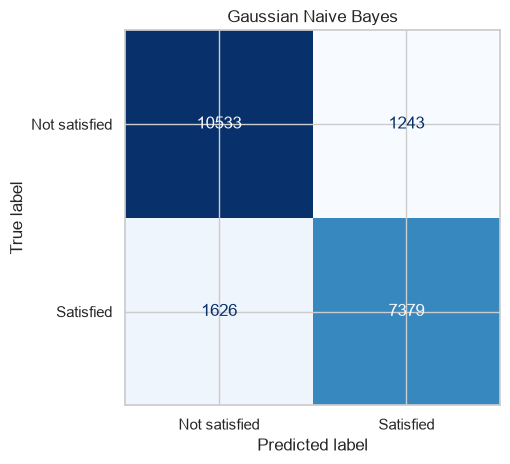

In [13]:
from sklearn.naive_bayes import GaussianNB

nb = Pipeline([("prep", clone(prep)), ("model", GaussianNB())])
evaluate("Gaussian Naive Bayes", nb)
show_cm("Gaussian Naive Bayes")

Gaussian Naive Bayes correctly classifies 86.19% of test passengers, with weighted F1 0.8615.

Naive Bayes actually did worse than logistic regression. That's probably because of the conditional independence assumption. Our EDA showed that many service ratings are correlated with each other, and NB can't model those relationships. When the assumptions don't hold, simpler models can outperform it.

## 4. Decision Tree

The tree divides passengers using feature thresholds. The search limits depth to control overfitting.

,Model,Baseline CV,Tuned CV,Change,Best parameters
0,Decision Tree,0.919164,0.919179,0.000015,{'model__max_depth': 12}


,Model,Accuracy,Precision weighted,Recall weighted,F1 weighted,ROC-AUC,Fit seconds
0,Decision Tree,0.9476,0.9476,0.9476,0.9475,0.9868,0.9151


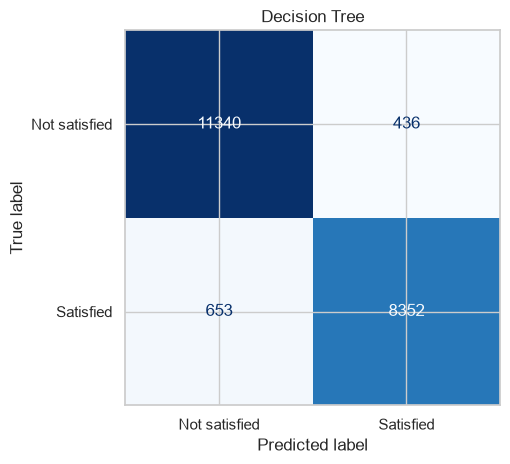

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = Pipeline([("prep", clone(prep)),
                 ("model", DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=42))])
tree = tune("Decision Tree", tree, {"model__max_depth": [5, 8, 12]})
evaluate("Decision Tree", tree)
show_cm("Decision Tree")

Decision Tree correctly classifies 94.76% of test passengers, with weighted F1 0.9475. Tuning changed the mean CV score by +0.00001.

The decision tree hit 94.76% with barely any tuning improvement. The tree visualization shows that online boarding alone does a lot of the heavy lifting as the first split. Trees are great at finding these clear decision rules in the data.

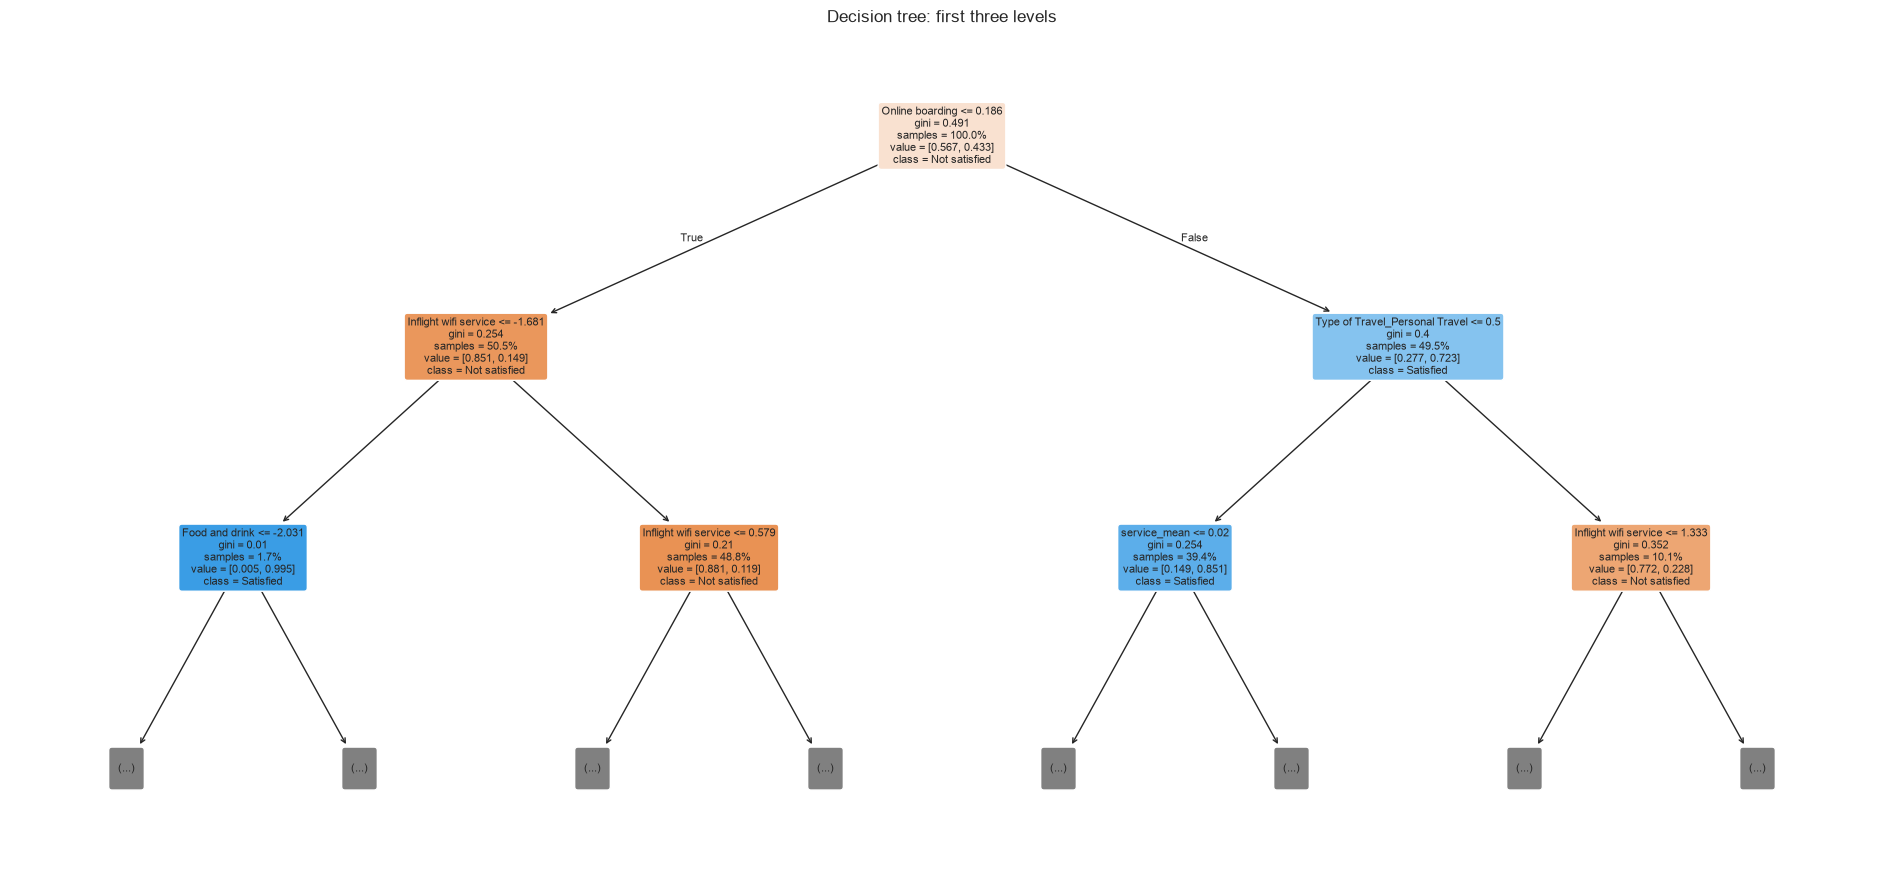

In [15]:
names = tree.named_steps["prep"].get_feature_names_out()
plt.figure(figsize=(19, 9))
plot_tree(tree.named_steps["model"], feature_names=names,
          class_names=["Not satisfied", "Satisfied"], max_depth=2,
          filled=True, rounded=True, fontsize=8, proportion=True)
plt.title("Decision tree: first three levels")
plt.tight_layout()
plt.show()

Online boarding forms the first split. Wi-Fi, travel type, and the engineered service average appear near the top. Only the first three levels are shown. Numeric thresholds are in standardized units.

## 5. SVC

SVC compares linear and RBF boundaries. C controls the penalty for training errors. Its decision scores are used directly for ROC-AUC.

,Model,Baseline CV,Tuned CV,Change,Best parameters
0,SVC,0.930047,0.930047,0.0,"{'model__C': 1, 'model__kernel': 'rbf'}"


,Model,Accuracy,Precision weighted,Recall weighted,F1 weighted,ROC-AUC,Fit seconds
0,SVC,0.953,0.9531,0.953,0.953,0.9886,116.4485


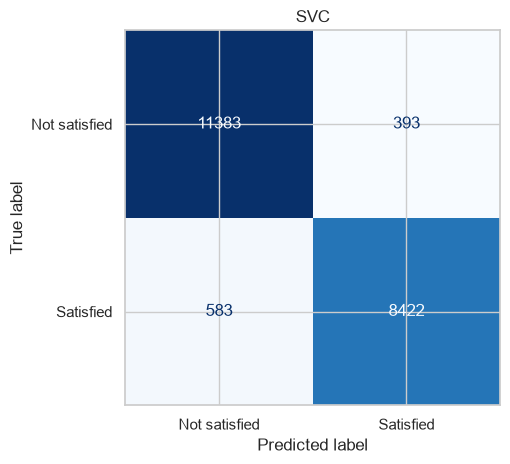

In [16]:
from sklearn.svm import SVC

svc = Pipeline([("prep", clone(prep)), ("model", SVC(cache_size=512, random_state=42))])
svc = tune("SVC", svc, {"model__C": [1, 10], "model__kernel": ["linear", "rbf"]})
evaluate("SVC", svc)
show_cm("SVC")

SVC correctly classifies 95.30% of test passengers, with weighted F1 0.9530. Tuning changed the mean CV score by +0.00000.

SVC is the best model so far at 95.30%. The RBF kernel lets it draw curved decision boundaries in the feature space, which seems to match the data well. The downside is that SVC is much slower to train than the tree-based models, especially on large datasets.

## Comparison

,Model,Accuracy,Precision weighted,Recall weighted,F1 weighted,ROC-AUC,Fit seconds
0,SVC,0.9530,0.9531,0.9530,0.9530,0.9886,116.4485
1,Decision Tree,0.9476,0.9476,0.9476,0.9475,0.9868,0.9151
2,KNN,0.9334,0.9334,0.9334,0.9332,0.9745,0.2959
3,Logistic Regression,0.8766,0.8764,0.8766,0.8763,0.9294,0.4731
4,Gaussian Naive Bayes,0.8619,0.8617,0.8619,0.8615,0.9216,0.3215


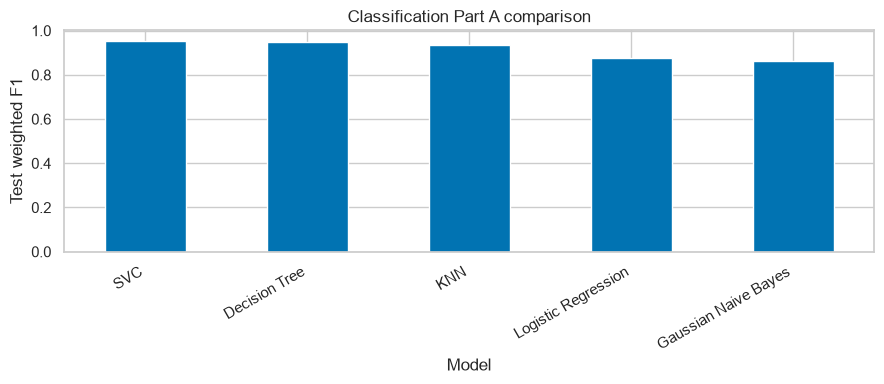

In [17]:
# compare all five models, sorted by weighted F1
results = pd.DataFrame(rows).sort_values("F1 weighted", ascending=False).reset_index(drop=True)
display(results.round(4))
results.plot.bar(x="Model", y="F1 weighted", legend=False, figsize=(9, 4))
plt.title("Classification Part A comparison")
plt.xlabel("Model")
plt.ylabel("Test weighted F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The comparison is ranked by weighted F1. Weighted recall equals accuracy for this single-label classification problem.

The results show a clear pattern: models that can capture nonlinear relationships (SVC, Decision Tree, KNN) do much better than linear ones (Logistic Regression, Naive Bayes). This tells us satisfaction depends on complex interactions between features, not just individual ratings.

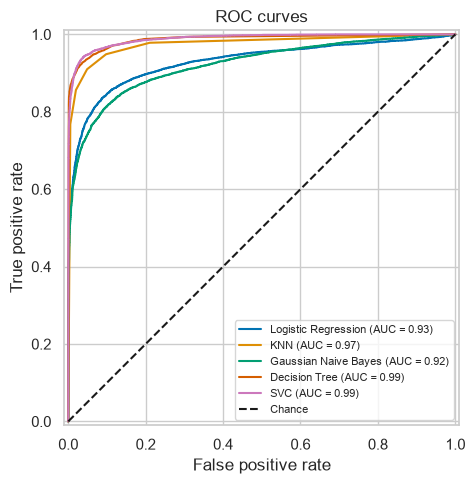

In [18]:
# overlay ROC curves to visually compare model discrimination
fig, ax = plt.subplots(figsize=(7, 5))
for name, score in scores_test.items():
    RocCurveDisplay.from_predictions(y_test, score, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Chance")
ax.set(title="ROC curves", xlabel="False positive rate", ylabel="True positive rate")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

SVC and the decision tree have the strongest ROC curves. Logistic regression and Naive Bayes separate the classes less clearly across the thresholds.

The ROC curves confirm the rankings. SVC and the decision tree hug the top-left corner tightly, meaning they achieve high true-positive rates without many false positives. The gap between the top and bottom models is quite visible here.

## Cross-validation

The two leading models are checked with five folds of the full training set. The parameters were chosen using training data, so these CV scores can be optimistic.

In [19]:
# 5-fold CV on top 2 models to check if test performance is stable
top = results["Model"].head(2).tolist()
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
for name in top:
    scores = cross_val_score(clone(fitted[name]), x_train, y_train, cv=cv5, scoring=scoring)
    row = {"Model": name, "CV mean": scores.mean(), "CV std": scores.std()}
    for i, value in enumerate(scores):
        row["Fold " + str(i + 1)] = value
    cv_rows.append(row)
cv_results = pd.DataFrame(cv_rows)
display(cv_results.round(4))

,Model,CV mean,CV std,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
0,SVC,0.9512,0.0021,0.9533,0.9524,0.9481,0.9491,0.953
1,Decision Tree,0.9469,0.0029,0.9473,0.9504,0.9454,0.9423,0.949


In [20]:
# save comparison table and tuning details for the report
results.to_csv("../results/airline_comparison.csv", index=False)
pd.DataFrame(tune_rows).to_csv("../results/airline_tuning.csv", index=False)
cv_results.to_csv("../results/airline_top_two_cv.csv", index=False)

## Conclusion

SVC leads with 95.30% accuracy, weighted F1 0.9530, and ROC-AUC 0.9886. Its five-fold weighted F1 is 0.9512 with a standard deviation of 0.0021.

The decision tree is close in accuracy and trains much faster. SVC makes 976 mistakes on the 20,781 test passengers, including 583 satisfied passengers predicted as not satisfied.

The stronger nonlinear models suggest that satisfaction depends on combinations of service ratings and travel details. The remaining confusion-matrix errors show that these inputs still do not explain every passenger's experience.